# Introduction to Quantum Computing with Qiskit

This notebook starts from zero. You do not need previous experience with quantum physics or linear algebra. You need only basic Python, such as variables, loops, and functions.

We will use a simulator, which is an ordinary program that calculates what a small ideal quantum computer would do. The final topic is a small demonstration of Shor's factoring algorithm for the number 15.

The work time for this notebook is 2-3 hours, so work through as much as you can, take the rest home, and ask whatever questions you may have! 

## What you will learn

| Section | Topic |
|:---:|:---:|
| 1 | Qubits, measurement, probability, and histograms |
| 2 | Gates that change one qubit |
| 3 | Gates that connect qubits |
| 4 | Entanglement |
| 5 | The Quantum Fourier Transform |
| 6 | A small, simulated Shor's algorithm example |

## A tiny math primer

A **vector** is an ordered list of numbers. In this notebook, a one-qubit state is represented by two numbers: one for the possibility of measuring 0 and one for the possibility of measuring 1. These numbers are called **amplitudes**. An amplitude can be negative or complex, so it is not itself a probability. To obtain a probability, take its magnitude and square it.

For example, the state $\frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$ has amplitude $1/\sqrt{2}$ for each outcome. Each probability is $(1/\sqrt{2})^2 = 1/2$. The probabilities of all possible outcomes must add to 1.

You will see $i$, the imaginary unit, in some gate definitions. It is defined by $i^2=-1$. You do not need to calculate with it by hand here. It lets quantum states carry phase information, which gates can later turn into observable probability changes. Phase is the angle associated with a quantum amplitude; differences in phase determine how amplitudes reinforce or cancel one another when they combine. For example, amplitudes $+1/\sqrt{2}$ and $-1/\sqrt{2}$ each give the same probability, $1/2$, but have opposite phases, so they cancel if added together.

You may also see phase written as $e^{i\theta}$, where $\theta$ is an angle. This is a compact way to describe a rotation in the complex-number plane: $e^{i0}=1$, $e^{i\pi/2}=i$, $e^{i\pi}=-1$, and $e^{i\pi/4}$ is a 45-degree rotation. Multiplying an amplitude by $e^{i\theta}$ changes its angle by $\theta$ without changing its magnitude, so its immediate measurement probability stays the same.

## Reading results: histograms

The bar graphs used throughout this notebook are called **histograms**. Each label along the bottom is a measurement outcome, such as `0`, `1`, or `101`. The height of its bar is the number of times that outcome appeared after repeating the circuit. A circuit is run many times because a single quantum measurement is random whenever more than one outcome has nonzero probability. In Qiskit, one repetition is called a **shot**.

Qiskit prints bit strings with the highest-indexed classical bit on the left. For a two-qubit circuit measured with `measure([0, 1], [0, 1])`, the displayed string `10` means classical bit 1 is 1 and classical bit 0 is 0. The comments in each example point this out when it matters.


## 0. Setup

Run the next cell once in a new notebook environment. It installs Qiskit, the Python toolkit used to describe quantum circuits, and Aer, the simulator used to run them.


In [10]:
# Install the packages needed by this notebook. Run this once per environment.
%pip install -q qiskit==2.5.2 qiskit-aer==0.17.2 pylatexenc matplotlib==3.11.2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Install the packages needed by this notebook. Run this once per environment.

In [8]:
# Imports used throughout the notebook.
from qiskit import QuantumCircuit, transpile
try:
    from qiskit_aer import AerSimulator
    simulator = AerSimulator()
    AER_AVAILABLE = True
except ImportError:
    # This fallback supports the ideal examples if Aer was not installed yet.
    from qiskit.providers.basic_provider import BasicSimulator
    simulator = BasicSimulator()
    AER_AVAILABLE = False
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import gcd, pi
from fractions import Fraction

print("All set! Qiskit is ready to go.")
if not AER_AVAILABLE:
    print("Aer was not found, so the ideal examples will use Qiskit's BasicSimulator.")


All set! Qiskit is ready to go.


---
## 1. Qubits, measurement, and your first circuit

### Bits and qubits

A classical **bit** stores exactly one of two values: 0 or 1. A **qubit** also gives 0 or 1 when measured, but before measurement it can be in a **superposition**, a state that assigns amplitudes to both outcomes.

We use **Dirac notation**: $|0\rangle$ means the state that always measures as 0, and $|1\rangle$ means the state that always measures as 1. The labels 0 and 1 inside the kets are just names, chosen to match the classical bit value that state will output when measured, not something derived. A general one-qubit state is

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle.$$

Here $\alpha$ and $\beta$ are amplitudes. Measurement produces 0 with probability $|\alpha|^2$ and 1 with probability $|\beta|^2$. The notation $|z|$ means the magnitude of $z$. The rule $|\alpha|^2+|\beta|^2=1$ makes the total probability equal to 1.

### Circuits and measurement

A quantum **circuit** is a sequence of instructions applied from left to right. It has quantum wires, called qubits, and classical wires, called classical bits. Measurement transfers one qubit's result into one classical bit and ends the quantum part of that qubit's story for this circuit.


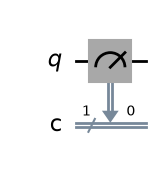

In [14]:
# Create a circuit with 1 qubit and 1 classical bit
qc = QuantumCircuit(1, 1)

# Measure qubit 0, store the result in classical bit 0
qc.measure(0, 0)

# Draw the circuit
qc.draw("mpl")

**How to read these circuit diagrams:**
- **q** is the qubit line, this is your 1 quantum bit, starting in state |0⟩.
- **c** is the classical bit line, this is where measurement results get stored as ordinary 0s and 1s.
- The box with the **meter/gauge symbol** (⌒/) is the **measurement gate** — it's the operation that reads the qubit's state and converts it into a classical bit.
- The **arrow** pointing from q down to c shows *where* the result goes: qubit 0's measurement result is written into classical bit 0.
- The **"1"** above the c line is the width of the classical register (how many classical bits exist total, here, just 1). The **"0"** below it is the specific bit index being written to, not the value output of the qubit. To see the actual measured value(s), you need to simulate the circuit over many attempts (shots, discussed soon) and plot the results, usually with a histogram (`plot_histogram`), since a single run only gives one outcome and quantum results are inherently probabilistic across many runs.
- The **double diagonal line (⫽)** on the c line is notation meaning "this is a classical wire carrying multiple bits" (even though here it's just 1), it's just how Qiskit distinguishes classical wires from quantum wires visually.

Every qubit begins in $|0⟩$ unless we change it. The next cell repeats a measurement 1,000 times. The histogram should have one bar, `0`, with a height of 1,000.


Results: {'0': 1000}


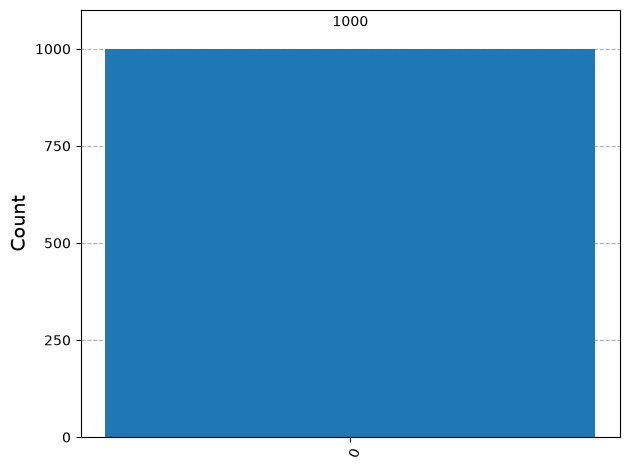

In [15]:
# Run the circuit 1000 times on the simulator
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()

print("Results:", counts)
plot_histogram(counts)

**Running the circuit**
- **`transpile(qc, simulator)`** rewrites your circuit into the specific gate set and layout the chosen simulator (or real hardware) actually understands, without changing what the circuit does. Every circuit needs this step before it can run.
- **`simulator.run(compiled, shots=1000)`** executes the compiled circuit 1000 times independently. Each run is called a **shot**. You need many shots because a single measurement only gives you one random outcome, and quantum results are probabilistic, so repeating it many times lets you see the actual probability distribution.
- **`.result()`** collects the outcomes from all 1000 shots into a result object.
- **`.get_counts()`** tallies those outcomes into a dictionary, like `{'0': 507, '1': 493}`, showing how many times each bitstring was measured. This is what you'll typically feed into `plot_histogram()` to visualize.

As expected, every shot returned `0`. The histogram is useful because it shows the distribution of results at a glance. We will next use gates to change that distribution.


---
## 2. Single-qubit gates

A **gate** is an operation on a qubit. Quantum gates are the analog of classical gates that operate on classical bits. Think of it as one instruction in a circuit. Gates are reversible before measurement, meaning that their effect can be undone by another gate.

### X gate, also called NOT

The X gate exchanges the two basis states:

$$X|0\rangle=|1\rangle, \qquad X|1\rangle=|0\rangle.$$

It is the quantum counterpart of a classical NOT operation.


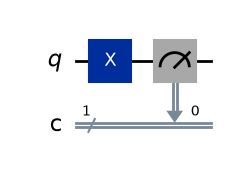

In [16]:
# Apply an X gate, then measure
qc = QuantumCircuit(1, 1)
qc.x(0)          # Flip qubit 0
qc.measure(0, 0)
qc.draw("mpl")

Results: {'1': 1000}


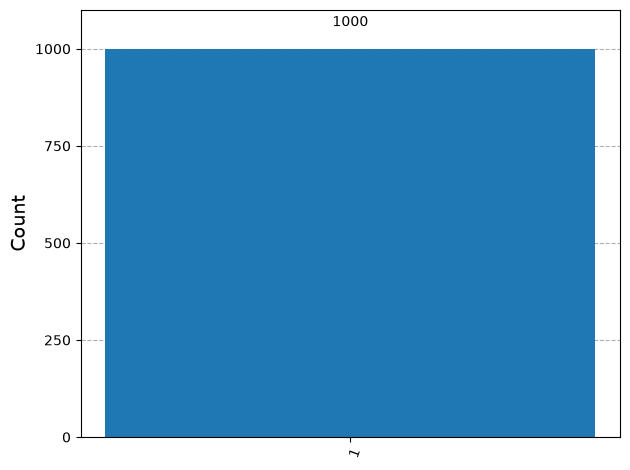

In [17]:
# Run the X-gate circuit. Every shot should measure 1.
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()
print("Results:", counts)
plot_histogram(counts)

### Hadamard gate, H

The Hadamard gate changes how the two possible outcomes combine. Applied to a qubit that starts as 0 or 1, it creates an even split between measuring 0 and measuring 1.

Mathematically:

$$H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle), \qquad H|1\rangle = \frac{1}{\sqrt{2}}(|0\rangle-|1\rangle).$$

Both outputs have the same $1/\sqrt{2}$ size on each term, so $|amplitude|^2 = 1/2$ either way, and an even 50/50 split when measured. The only difference between the two is a sign on the $|1\rangle$ term, plus in the first case, minus in the second.

If a qubit is already in a superposition, H does not simply put it "in superposition again." It combines the parts already there. They can reinforce one outcome and cancel the other, so H can turn an equal superposition into a state that will measure as definitely 0 or definitely 1. For example, applying $H$ to $\frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$ gives back $|1\rangle$ exactly, the minus sign caused the $|0\rangle$ terms to cancel and the $|1\rangle$ terms to add up.

H itself does not collapse the state; measurement does. Instead, H changes the state so that the later measurement can have a different result.

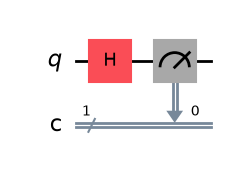

In [18]:
# Put a qubit in superposition and measure
qc = QuantumCircuit(1, 1)
qc.h(0)           # Apply Hadamard
qc.measure(0, 0)
qc.draw("mpl")

Results: {'0': 502, '1': 498}


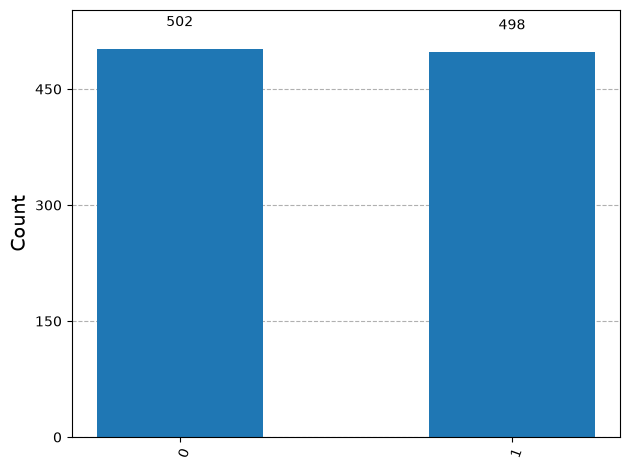

In [22]:
# Run the H-gate circuit. The histogram should be close to 50% 0 and 50% 1. It won't be exact!
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()
print("Results:", counts)
plot_histogram(counts)

### Phase gates: Z, S, and T

The Z, S, and T gates change **phase**, which is the angle of an amplitude in the complex-number plane. They leave the $|0\rangle$ amplitude unchanged and rotate the $|1\rangle$ amplitude without changing its measurement probability.

$$Z|1\rangle=-|1\rangle=e^{i\pi}|1\rangle \quad \text{(180-degree rotation)}$$

$$S|1\rangle=i|1\rangle=e^{i\pi/2}|1\rangle \quad \text{(90-degree rotation)}$$

$$T|1\rangle=e^{i\pi/4}|1\rangle \quad \text{(45-degree rotation)}$$

An immediate measurement may show the same histogram, but later gates can use interference to turn these phase differences into different measurement probabilities.

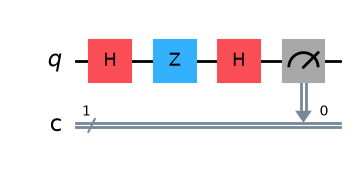

In [28]:
# H creates equal amplitudes. Z changes the sign of the |1> amplitude.
# The final H lets those amplitudes interfere, so the phase change becomes measurable.
qc_z = QuantumCircuit(1, 1)
qc_z.h(0)
qc_z.z(0)
qc_z.h(0)
qc_z.measure(0, 0)
qc_z.draw("mpl")

H, then Z, then H: {'1': 1000}


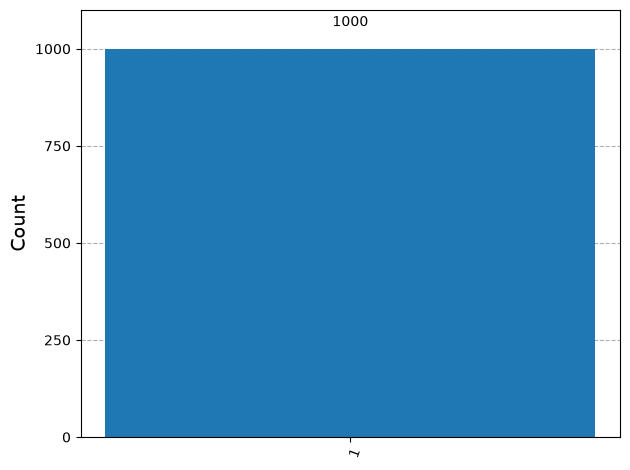

In [29]:
# Simulate the circuit.
compiled = transpile(qc_z, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()
print("H, then Z, then H:", counts)
plot_histogram(counts)

This circuit applies H, then Z, then H again, and every measurement comes out `1`, with no randomness. Here's why.

The first `h(0)` puts the qubit into an equal mix of $|0\rangle$ and $|1\rangle$: $(|0\rangle+|1\rangle)/\sqrt{2}$. Measuring here would give 0 or 1 with 50/50 probability.

`z(0)` doesn't change those probabilities, it flips the sign on the $|1\rangle$ part only: $(|0\rangle-|1\rangle)/\sqrt{2}$. If you measured right now, you'd still get 50/50, that sign flip is invisible to a direct measurement.

The second `h(0)` is what makes the sign flip visible. Applying H again causes the $|0\rangle$ and $|1\rangle$ parts to combine, and because of that earlier sign flip, they combine into pure $|1\rangle$ instead of back into the original state. This combining effect, where amplitudes add up or cancel out depending on their signs, is called **interference**, and it's why the final measurement is guaranteed to be 1, not random at all.


### Exercise 1: predict, build, and check

For each circuit, predict whether the histogram will show only `0`, only `1`, or a roughly even split. Then run the starter cell. Every circuit must end with `measure(0, 0)` because a simulator cannot put a quantum result into a histogram until it is measured.

1. `X`, then `H`, then measurement, beginning in $|0\rangle$.
2. `H`, then `X`, then `H`, then measurement, beginning in $|0\rangle$.
3. `H`, then `H`, then measurement, beginning in $|0\rangle$. Hint: $H$ is its own inverse.


In [ ]:
# Exercise 1 starter circuits. These are complete and runnable examples.
# Read the gate order, predict the result, then compare with the printed counts.
def run_one_qubit(circuit, label):
    compiled = transpile(circuit, simulator)
    counts = simulator.run(compiled, shots=1000).result().get_counts()
    print(label, counts)
    return counts

qc1 = QuantumCircuit(1, 1)
qc1.x(0)
qc1.h(0)
qc1.measure(0, 0)
run_one_qubit(qc1, "1. X then H:")

qc2 = QuantumCircuit(1, 1)
qc2.h(0)
qc2.x(0)
qc2.h(0)
qc2.measure(0, 0)
run_one_qubit(qc2, "2. H then X then H:")

qc3 = QuantumCircuit(1, 1)
qc3.h(0)
qc3.h(0)
qc3.measure(0, 0)
run_one_qubit(qc3, "3. H then H:"); # Semicolon suppresses the duplicate auto-printed return value (housekeeping addition).


1. X then H: {'0': 497, '1': 503}
2. H then X then H: {'0': 1000}
3. H then H: {'0': 1000}


### Exercise 1 explanation

Circuit 1 ends in an equal superposition, so it is roughly 50/50. Circuit 2 always returns `1`, because $HXH=Z$ and Z changes the phase after the first H in a way that the final H turns into a bit flip. Circuit 3 always returns `0`, because $HH=I$, where $I$ is the identity operation that changes nothing.


X then H {'0': 498, '1': 502}


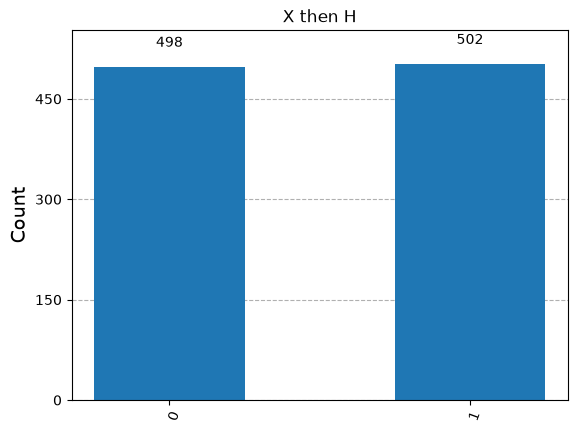

H then X then H {'0': 1000}


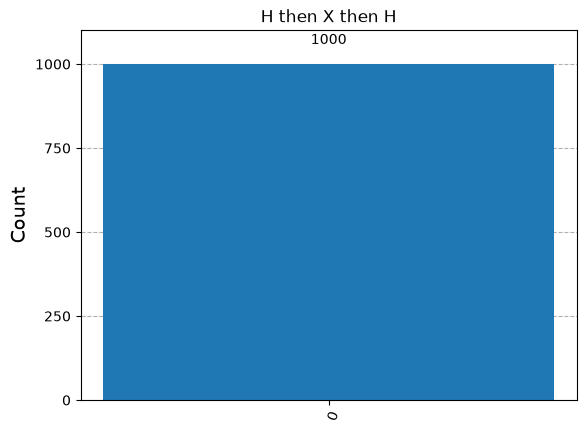

H then H {'0': 1000}


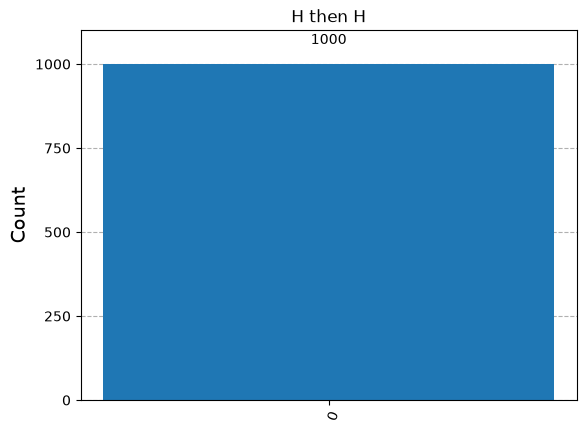

In [33]:
# Exercise 1 solution visualized as three histograms.
for circuit, label in [(qc1, "X then H"), (qc2, "H then X then H"), (qc3, "H then H")]:
    counts = run_one_qubit(circuit, label)
    fig, ax = plt.subplots()
    plot_histogram(counts, title=label, ax=ax)
    plt.show()

---
## 3. Gates that connect qubits (multi-qubit gates)

So far, each gate has acted on one qubit at a time. A **multi-qubit gate** acts on two or more qubits together. This lets us do things such as flip one qubit depending on another qubit's value, or exchange the states of two qubits. We will start with a conditional flip, then try the Toffoli and SWAP gates.

### CNOT gate, also called controlled-X or CX

Remember that the X gate flips $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$. **CNOT** means **controlled-NOT**: it applies that same flip to one qubit, but only when a second qubit is in $|1\rangle$.

The two qubits have different jobs:

- The **control** determines whether the flip happens. If it is 0, leave the target alone; if it is 1, flip the target.
- The **target** is the qubit that receives the X operation when the control is 1.

For inputs that are definitely 0 or 1, the full rule is:

| Control before | Target before | Control after | Target after |
|:---:|:---:|:---:|:---:|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 1 |
| 1 | 0 | 1 | 1 |
| 1 | 1 | 1 | 0 |

Notice that the control's value stays the same. The target is **flipped**, not simply set to 1: if both inputs are 1, the target becomes 0. Applying the same CNOT twice undoes the flip and returns the original state.

In Qiskit, `qc.cx(0, 1)` makes qubit 0 the control and qubit 1 the target. The first argument is the control, and the second is the target. In the circuit drawing, a filled dot marks the control and a circled plus marks the target; a line joins them to show that they belong to the same gate.

### Walk through the next two examples

Every qubit starts in $|0\rangle$. In the first circuit below, the control is 0, so CNOT leaves the target at 0. Every shot should give `00`.

In the second circuit, `qc.x(0)` first changes the control to 1. CNOT then flips the target from 0 to 1, so every shot should give `11`.

Both circuits use `qc.measure([0, 1], [0, 1])`, which stores qubit 0's result in classical bit 0 and qubit 1's result in classical bit 1. Remember that Qiskit displays these results as `c1c0`, so the target's result is on the left and the control's result is on the right.

### CNOT Aside:

CNOT applies its flip rule directly to the quantum state, it never checks or collapses anything first. If the control qubit is in superposition, that superposition has multiple terms, and CNOT acts on each term separately, using its normal rule: flip the target if that term's control value is 1, leave it if that term's control value is 0.

For example, if $q_0$ is in superposition $(|0\rangle+|1\rangle)/\sqrt{2}$ and $q_1$ starts at $|0\rangle$, the joint state is $(|00\rangle+|10\rangle)/\sqrt{2}$. CNOT(control=$q_0$, target=$q_1$) leaves the $|00\rangle$ term alone (control is 0) and flips the $|10\rangle$ term to $|11\rangle$ (control is 1), giving $(|00\rangle+|11\rangle)/\sqrt{2}$.

Now $q_0$ and $q_1$ can't be described separately, measuring one instantly tells you the other. That correlation is **entanglement**, and you'll build it directly in Section 4.
For now, the two examples below use a control that's already definite (0 or 1), so you can check the conditional-flip rule in its simplest form before superposition enters the picture.

Control q0 = |0> (so target q1 stays |0>):


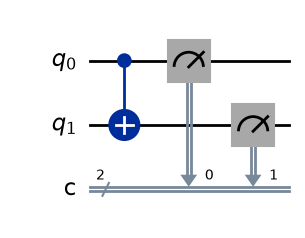

In [34]:
# Two qubits (q0, q1) and two classical result slots (c0, c1).
# Start with q0 = 0, so this CNOT should not change q1.
qc = QuantumCircuit(2, 2)
# cx(control, target): q0 is the control and q1 is the target.
# q1 flips only when q0 is 1; q0 itself is never changed.
qc.cx(0, 1)
# measure([qubits], [classical bits]): each position pairs up, so q0's result goes to c0 and q1's result goes to c1.
# Qiskit prints results as c1c0, so the leftmost displayed bit is q1's result.
qc.measure([0, 1], [0, 1])
print("Control q0 = |0> (so target q1 stays |0>):")
qc.draw("mpl")

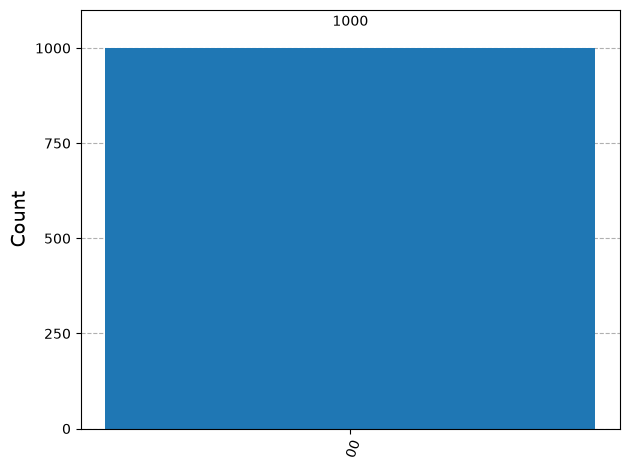

In [35]:
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
plot_histogram(result.get_counts())

As expected, q1 never flips since the control q0 was 0. Both bits report as 0 with certainty, no other outcome is possible here.

Control = |1>:


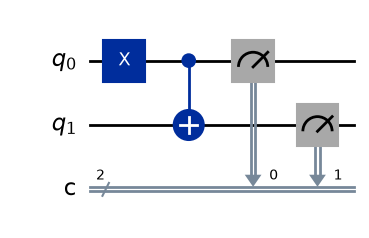

In [36]:
# Now flip the control to |1> first, then CNOT
qc = QuantumCircuit(2, 2)
qc.x(0)            # Set control to |1>
qc.cx(0, 1)        # CNOT: now the target flips!
qc.measure([0, 1], [0, 1])
print("Control = |1>:")
qc.draw("mpl")

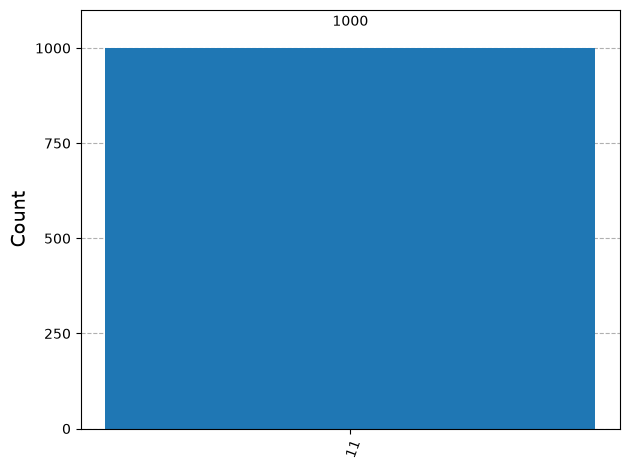

In [37]:
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
plot_histogram(result.get_counts())

Now that q0 is 1, the CNOT actually fires, flipping q1 to match. This is the entangling behavior CNOT is named for: the target's outcome depends entirely on the control's state.

### Toffoli gate, also called CCX

The Toffoli gate has two controls and one target. It flips the target only when both controls are 1. In Qiskit, `ccx(control_a, control_b, target)` applies it. It is useful because it provides conditional logic with more than one condition.


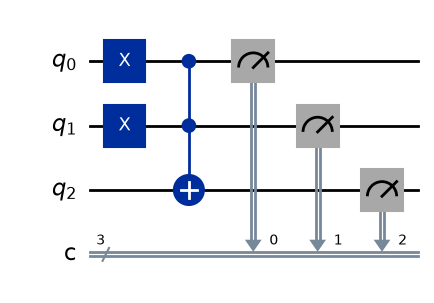

In [39]:
# Toffoli: both controls must be |1> to flip the target
qc = QuantumCircuit(3, 3)
qc.x(0)              # Control 1 = |1>
qc.x(1)              # Control 2 = |1>
qc.ccx(0, 1, 2)      # Toffoli: flip qubit 2, so now due to the 2 X gates and the Toffoli, we get |111>, which we see in the histogram output in the next cell.
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

Both controls |1> -> target flips to |1>:


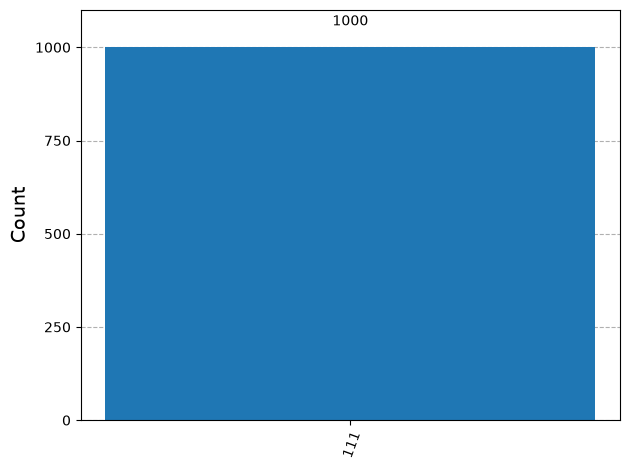

In [40]:
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
print("Both controls |1> -> target flips to |1>:")
plot_histogram(result.get_counts())

The Toffoli only flips its target when *both* controls are 1, so this is a stricter, two-condition version of the single-control CNOT you saw previously.

### SWAP gate

`swap(a, b)` exchanges the complete states of two qubits. If qubit 0 is 1 and qubit 1 is 0, then a SWAP makes qubit 0 equal 0 and qubit 1 equal 1. It is not a measurement or a copy: it is a reversible exchange.


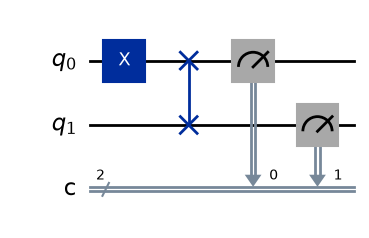

In [43]:
# SWAP: exchange qubit 0 (|1>) and qubit 1 (|0>)
qc = QuantumCircuit(2, 2)
qc.x(0)              # qubit 0 = |1>, qubit 1 = |0>
qc.swap(0, 1)        # Now qubit 0 = |0>, qubit 1 = |1>. What do you think this would output in the histogram as? Remember qiskit's leftmost-first convention!
qc.measure([0, 1], [0, 1])
qc.draw("mpl")

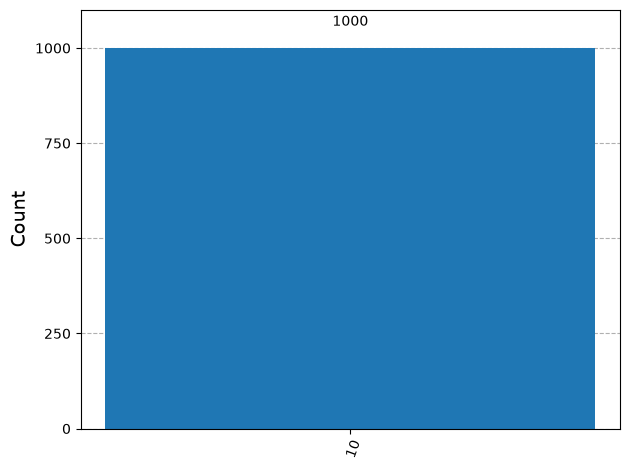

In [44]:
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
plot_histogram(result.get_counts())

Before the swap, q0 held `1` and q1 held `0`. After `swap(0, 1)`, those values trade places, so q0 becomes `0` and q1 becomes `1`. Reading the histogram as c1c0 (Qiskit's leftmost-first convention), `10` means c1=1 and c0=0, exactly the swapped result, with no randomness since no superposition was involved.

### Exercise 2: build a quantum half-adder

A half-adder takes two input bits and outputs their **sum** and **carry**, exactly like adding by hand: 1+1 = 0, carry 1.

Addition without carrying is just XOR, no gate is named "XOR," so your job is to find which gate (or combination) *behaves* like XOR for the sum, and which behaves like AND for the carry.

XOR Review:

| bit A | bit B | A XOR B |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

You have X, CNOT, and Toffoli. Combine them so qubit 2 ends up holding the sum, and qubit 3 ends up holding the carry, given inputs on qubits 0 and 1.

Test all four input combinations below and check against binary addition: 0+0=0 carry 0, 0+1=1 carry 0, 1+0=1 carry 0, 1+1=0 carry 1.

Once one input pair works, don't copy-paste four circuits. Wrap it in a function that takes `bit0` and `bit1`, using `if` to decide whether to add the `x` gates, then loop over the four pairs.

In [47]:
# Exercise 2: build a quantum half-adder.
# q0, q1 = the two input bits. q2 = sum output. q3 = carry output.
# Don't hardcode four separate circuits, write one function that takes
# bit0 and bit1 as arguments and builds the circuit for those inputs.

def half_adder(bit0, bit1):
    qc = QuantumCircuit(4, 4)

    # Set the two input qubits based on bit0 and bit1.
    if bit0 == 1:
        # ...
    if bit1 == 1:
        # ...

    # TODO: add the gates that make q2 hold the sum and q3 hold the carry.
    # You have qc.cx(control, target) and qc.ccx(control1, control2, target)
    # available. Think about how many gates you need for each output qubit.

    # ...

    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
    return qc

# Test all four input combinations.
for bit0, bit1 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    circuit = half_adder(bit0, bit1)
    counts = simulator.run(transpile(circuit, simulator), shots=1000).result().get_counts()
    print(f"{bit0} + {bit1}:", counts)

IndentationError: expected an indented block after 'if' statement on line 10 (1787003252.py, line 12)

### Exercise 2 explanation

The missing gates are:

```python
qc.cx(0, 2)
qc.cx(1, 2)
qc.ccx(0, 1, 3)
```


**Sum (qubit 2):** addition without carrying is XOR, and no gate is directly named XOR, but two CNOTs into the same target reproduce it. Each CNOT flips qubit 2 independently if its own control is 1. If only one input is 1, qubit 2 gets flipped once and lands on 1. If both inputs are 1, qubit 2 gets flipped twice, which cancels back to 0. If neither is 1, qubit 2 is never touched and stays 0. That's exactly the XOR table.

**Carry (qubit 3):** carry is 1 only when *both* inputs are 1, which is precisely what Toffoli already does by definition, flip the target only if both controls are 1. No combination needed here, just a direct application of the gate.

In [48]:
# Exercise 2 solution.
def half_adder(bit0, bit1):
    qc = QuantumCircuit(4, 4)
    if bit0 == 1:
        qc.x(0)
    if bit1 == 1:
        qc.x(1)

    qc.cx(0, 2)
    qc.cx(1, 2)
    qc.ccx(0, 1, 3)

    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])
    return qc

for bit0, bit1 in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    circuit = half_adder(bit0, bit1)
    counts = simulator.run(transpile(circuit, simulator), shots=1000).result().get_counts()
    print(f"{bit0} + {bit1}:", counts)

0 + 0: {'0000': 1000}
0 + 1: {'0110': 1000}
1 + 0: {'0101': 1000}
1 + 1: {'1011': 1000}


---
## 4. Building circuits: entanglement

### Bell state

**Entanglement** means that a multi-qubit state has correlations that cannot be described by giving each qubit its own independent state. It does not let us send information faster than light. It means that measurements of the qubits are related.

Apply H to qubit 0, then CNOT from qubit 0 to qubit 1:

$$|00\rangle \rightarrow \frac{|00\rangle+|11\rangle}{\sqrt{2}}.$$

Each individual qubit has a 50% chance to be 0 or 1. But if we measure both, we get either `00` or `11`; `01` and `10` never appear on an ideal simulator.


In [ ]:
# Create a Bell state
bell = QuantumCircuit(2, 2)
bell.h(0)             # Superposition on qubit 0
bell.cx(0, 1)         # Entangle qubit 1 with qubit 0
bell.measure([0, 1], [0, 1])

bell.draw("mpl")

In [ ]:
# Run it , only '00' and '11' should appear (never '01' or '10')
compiled = transpile(bell, simulator)
result = simulator.run(compiled, shots=1000).result()
plot_histogram(result.get_counts())

### Exercise 3: related entangled states

1. Make $(|01\rangle+|10\rangle)/\sqrt{2}$. Start with the Bell-state pattern, then use one X gate to flip either qubit before measurement. The only results should be `01` and `10`.
2. Make a three-qubit GHZ state, $(|000\rangle+|111\rangle)/\sqrt{2}$. Apply H to one qubit and use it as the control for CNOT gates to each remaining qubit. The only results should be `000` and `111`.

The code below is complete. Cover the solution lines mentally, predict the histogram, and then run it.


In [ ]:
# Exercise 3.1: make the other two-qubit Bell state.
qc_bell2 = QuantumCircuit(2, 2)
qc_bell2.h(0)
qc_bell2.cx(0, 1)
qc_bell2.x(0)  # Flipping one qubit turns 00/11 into 01/10.
qc_bell2.measure([0, 1], [0, 1])

# Exercise 3.2: make a GHZ state on three qubits.
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(0, 2)
qc_ghz.measure([0, 1, 2], [0, 1, 2])

for circuit, label in [(qc_bell2, "Modified Bell state"), (qc_ghz, "GHZ state")]:
    counts = simulator.run(transpile(circuit, simulator), shots=1000).result().get_counts()
    print(label + ":", counts)


### Exercise 3 explanation

Flipping one qubit maps each correlated Bell outcome to an anti-correlated outcome. The GHZ circuit extends the same pattern: the first H creates two possibilities, and each CNOT copies the value of the control into another qubit without measuring it. The result is a three-way correlation.


In [ ]:
# Show the Exercise 3 measurement distributions.
for circuit, label in [(qc_bell2, "Modified Bell state: 01 or 10"), (qc_ghz, "GHZ state: 000 or 111")]:
    counts = simulator.run(transpile(circuit, simulator), shots=1000).result().get_counts()
    plot_histogram(counts, title=label)
    plt.show()


---
## 5. The Quantum Fourier Transform, QFT

A **Fourier transform** changes a description from one form to another. A familiar analogy is a musical chord: a Fourier transform can describe it in terms of its component frequencies. The **Quantum Fourier Transform** (QFT) reorganizes amplitudes so that repeating patterns, called **periods**, become easier to measure.

For $n$ qubits there are $2^n$ possible basis states. The QFT maps one set of amplitudes across those states to another. Its full formula contains complex exponentials, but you do not need to calculate it manually. In this notebook, the important point is that the QFT is a reversible circuit made from H gates, controlled phase rotations, and SWAP gates.

A controlled phase rotation changes the phase of a target qubit only when its control is 1. The rotation angles become smaller for qubits farther apart in the circuit.


In [ ]:
def build_qft(n_qubits):
    """Return the standard QFT circuit for n_qubits, including final bit-order swaps."""
    circuit = QuantumCircuit(n_qubits, name="QFT")
    # Build from the highest-indexed qubit down. This ordering matches Qiskit's
    # little-endian qubit convention and is important for period finding.
    for target in reversed(range(n_qubits)):
        circuit.h(target)
        for control in range(target):
            angle = pi / (2 ** (target - control))
            circuit.cp(angle, control, target)
    for left in range(n_qubits // 2):
        circuit.swap(left, n_qubits - left - 1)
    return circuit

qft3 = build_qft(3)
qft3.draw("mpl")


The **inverse QFT**, written QFT$^\dagger$, reverses the QFT. In linear algebra, the dagger means conjugate transpose; operationally here, it means undo the circuit in reverse order with inverse phase rotations. Applying QFT and then inverse QFT returns the starting state.


In [ ]:
def build_inverse_qft(n_qubits):
    # Build the inverse QFT by reversing the QFT circuit.
    return build_qft(n_qubits).inverse()

inv_qft3 = build_inverse_qft(3)
inv_qft3.draw("mpl")

### Exercise 4: QFT round trip

Prepare the three-qubit binary value 5, written `101`, apply QFT, apply inverse QFT, and measure. Qiskit uses little-endian qubit indexing, so `101` requires qubits 0 and 2 to be set to 1. Because the second transform undoes the first, every ideal shot should return `101`.


In [ ]:
# Exercise 4: a complete QFT round trip on |101>, which is decimal 5.
qc = QuantumCircuit(3, 3)
qc.x(0)  # Rightmost bit of displayed 101.
qc.x(2)  # Leftmost bit of displayed 101.
qc.compose(qft3, inplace=True)
qc.compose(build_inverse_qft(3), inplace=True)
qc.measure([0, 1, 2], [0, 1, 2])

counts = simulator.run(transpile(qc, simulator), shots=1000).result().get_counts()
print("Expected result: 101. Actual result:", counts)
plot_histogram(counts, title="QFT followed by inverse QFT")


### Exercise 4 explanation

The QFT itself would produce a superposition with several amplitudes, so measuring in the middle would not preserve `101`. The inverse QFT must happen before measurement. Together, the two reversible transformations cancel, returning the state to `101`.


In [ ]:
# Verify the round trip directly. The assertion makes a wrong result visible immediately.
assert set(counts) == {"101"}, f"Expected only 101, received {counts}"
print("Verified: QFT followed by inverse QFT returned 101 in every shot.")


---
## 6. Shor's algorithm: factoring 15

### Why factoring matters

Factoring means writing a whole number as a product of smaller whole numbers. For example, $15=3\times5$. Some encryption systems rely on the fact that factoring a product of two very large prime numbers is difficult for known classical methods.

Shor's algorithm uses a quantum computer to solve a related task, **period finding**. This notebook demonstrates the idea on 15. It is a small educational circuit, not a practical attack on encryption.

### The classical idea first

Choose a number $a$ that has no factor in common with $N$. For $N=15$, choose $a=7$. Calculate $7^x \bmod 15$, where “mod 15” means keep the remainder after dividing by 15:

| x | $7^x \bmod 15$ |
|---|---|
| 0 | 1 |
| 1 | 7 |
| 2 | 4 |
| 3 | 13 |
| 4 | 1 |

The values repeat every four steps, so the **period** is $r=4$. Once a suitable even period is known, ordinary classical arithmetic gives the factors:

$$\gcd(7^{r/2}-1,15)=\gcd(48,15)=3, \qquad \gcd(7^{r/2}+1,15)=\gcd(50,15)=5.$$

`gcd` means greatest common divisor: the largest positive integer that divides both inputs.


### Registers and controlled multiplication

The circuit has two groups of qubits, called **registers**.

* The three-qubit counting register will hold information about the period after the inverse QFT.
* The four-qubit work register holds values from 0 through 15 in binary. It begins at $|1\rangle$.

Each counting qubit conditionally applies multiplication by a power of 7 modulo 15. For this small example, the multiplication operations can be built from controlled-SWAP and controlled-X gates. A controlled gate acts only when its control is 1. The circuit does not measure the work register; it uses it to create the interference pattern that the inverse QFT reads from the counting register.


In [ ]:
def controlled_mult_7_mod15(circuit, control, work_qubits):
    """Apply x -> 7x mod 15 to the work register when control is 1."""
    q0, q1, q2, q3 = work_qubits  # q0 is the least-significant work bit.
    circuit.cswap(control, q0, q1)
    circuit.cswap(control, q1, q2)
    circuit.cswap(control, q2, q3)
    for qubit in work_qubits:
        circuit.cx(control, qubit)

def controlled_mult_4_mod15(circuit, control, work_qubits):
    """Apply x -> 4x mod 15 to the work register when control is 1."""
    q0, q1, q2, q3 = work_qubits
    circuit.cswap(control, q0, q2)
    circuit.cswap(control, q1, q3)

print("Controlled modular multiplication functions are ready.")


Before building the full circuit, verify the two custom multiplication operations. The work register is initialized to binary 1. With the control set to 1, multiplying by 7 should give `0111`, and multiplying by 4 should give `0100`.


In [ ]:
# Verify: multiply |1> by 7 mod 15 should give |7>
test = QuantumCircuit(5, 4)  # 1 control + 4 work
test.x(0)                     # Control = |1> (activate the gate)
test.x(1)                     # Work register = |0001> = 1

controlled_mult_7_mod15(test, control=0, work_qubits=[1, 2, 3, 4])
test.measure([1, 2, 3, 4], [0, 1, 2, 3])

compiled = transpile(test, simulator)
result = simulator.run(compiled, shots=100).result()
print("7 * 1 mod 15 =", result.get_counts())
# Should give '0111' = 7

In [ ]:
# Verify: multiply |1> by 4 mod 15 should give |4>
test = QuantumCircuit(5, 4)
test.x(0)                     # Control on
test.x(1)                     # Work = |0001> = 1

controlled_mult_4_mod15(test, control=0, work_qubits=[1, 2, 3, 4])
test.measure([1, 2, 3, 4], [0, 1, 2, 3])

compiled = transpile(test, simulator)
result = simulator.run(compiled, shots=100).result()
print("4 * 1 mod 15 =", result.get_counts())
# Should give '0100' = 4

### Putting the period-finding circuit together

The H gates place the counting register into a superposition of possible exponents. The controlled multiplications encode the repeating pattern into the combined state. The inverse QFT changes that pattern into measurement peaks. The histogram will have peaks at `000`, `010`, `100`, and `110`; values 2 and 6 reveal the denominator 4 directly.


In [ ]:
def build_inverse_qft(n_qubits):
    """Return a circuit that exactly reverses build_qft(n_qubits)."""
    return build_qft(n_qubits).inverse()

def shors_circuit_15():
    """Period-finding circuit for N=15 and a=7, using three counting qubits."""
    n_count, n_work = 3, 4
    circuit = QuantumCircuit(n_count + n_work, n_count)
    work = list(range(n_count, n_count + n_work))
    for qubit in range(n_count):
        circuit.h(qubit)
    circuit.x(work[0])  # Work register begins in |0001>, the value 1.
    circuit.barrier()
    controlled_mult_7_mod15(circuit, control=0, work_qubits=work)  # 7^(2^0)
    controlled_mult_4_mod15(circuit, control=1, work_qubits=work)  # 7^(2^1)
    # 7^(2^2) mod 15 is 1, so the third controlled operation is identity.
    circuit.compose(build_inverse_qft(n_count), qubits=range(n_count), inplace=True)
    circuit.measure(range(n_count), range(n_count))
    return circuit

shor_qc = shors_circuit_15()
shor_qc.draw("mpl", fold=40)


### Run the period-finding circuit

The exact bar heights vary because measurement is sampled. The important feature is the locations of the peaks. A clean simulation should concentrate nearly all results in `000`, `010`, `100`, and `110`.


In [ ]:
# Run the circuit!
compiled = transpile(shor_qc, simulator)
result = simulator.run(compiled, shots=2048).result()
counts = result.get_counts()

print("Measurement results:")
print(counts)
plot_histogram(counts)

### Interpret the measurements

For three counting qubits there are $2^3=8$ possible measured values. A measurement $s$ represents the fraction $s/8$. A **continued fraction** is a way to approximate a decimal by a fraction with a small denominator. Here it helps recover a candidate period from a measured fraction.

For example, `010` is decimal 2, so $s/8=2/8=1/4$. Its denominator is 4, the period we want. `110` gives $6/8=3/4$, which has the same denominator. `000` contains no useful period information, and `100` gives 1/2, which is a divisor of the true period and must be checked.


In [ ]:
def interpret_results(counts, n_count, N, a):
    """Use measured phases to test candidate periods and return factors found."""
    denominator = 2 ** n_count
    factors_found = set()
    print(f"Factoring N={N} with a={a}; counting-register denominator={denominator}")
    for output_bits, count in sorted(counts.items(), key=lambda item: -item[1]):
        s = int(output_bits, 2)
        if s == 0:
            print(f"{output_bits}: {count} shots, no period information")
            continue
        fraction = Fraction(s, denominator).limit_denominator(N)
        r = fraction.denominator
        print(f"{output_bits}: {count} shots, {s}/{denominator} = {fraction}, candidate r={r}")
        if r % 2:
            print("  Candidate period is odd, so skip it.")
            continue
        for candidate in (gcd(a ** (r // 2) - 1, N), gcd(a ** (r // 2) + 1, N)):
            if 1 < candidate < N:
                factors_found.add(candidate)
    factors = sorted(factors_found)
    if len(factors) >= 2:
        print(f"Factors found: {factors[0]} x {factors[1]} = {N}")
    else:
        print("No complete factor pair was recovered from these samples.")
    return factors

factors = interpret_results(counts, n_count=3, N=15, a=7)


### What just happened

The quantum part did not directly output “3” and “5.” It produced measurements that reveal the period of $7^x mod 15$. The classical continued-fraction and greatest-common-divisor steps then converted that period into factors. This division of labor is central to Shor's algorithm.


---
## 7. Further experiments

These experiments are complete, runnable extensions. They show how changing the base, the number of counting qubits, and the noise model affects the same core idea.


### Challenge A: use base a = 2

For $a=2$ and $N=15$, the values $2^x mod 15$ repeat with period 4. Multiplication by 2 rotates the four work bits one position toward higher significance, wrapping the highest bit around to the lowest. Three controlled-SWAP gates implement that rotation. Multiplication by 4 is a two-position rotation.


### Challenge A · New base , implement $a = 2$

Modify the Shor's circuit to use $a = 2$ instead of $a = 7$ for factoring
$N = 15$.

The period is still $r = 4$, but the gate decomposition for "multiply by 2
mod 15" is different. Work out the permutation first, then figure out which
SWAP/X gates implement it.

| Input | $2x \bmod 15$ | Binary in | Binary out |
|:-----:|:-----:|:-----:|:-----:|
| 1 | 2 | `0001` | `0010` |
| 2 | 4 | `0010` | `0100` |
| 4 | 8 | `0100` | `1000` |
| 8 | 1 | `1000` | `0001` |

Look at the binary columns , the bits are cycling one position to the left
(with wraparound). That's a circular shift, which can be done with three
SWAPs.

In [ ]:
def controlled_mult_2_mod15(circuit, control, work_qubits):
    """Apply x -> 2x mod 15 when control is 1, a one-place circular bit shift."""
    q0, q1, q2, q3 = work_qubits
    circuit.cswap(control, q2, q3)
    circuit.cswap(control, q1, q2)
    circuit.cswap(control, q0, q1)

def controlled_mult_4_mod15_a2(circuit, control, work_qubits):
    """Apply x -> 4x mod 15 when control is 1, a two-place circular bit shift."""
    q0, q1, q2, q3 = work_qubits
    circuit.cswap(control, q0, q2)
    circuit.cswap(control, q1, q3)

def shors_circuit_15_a2():
    n_count, n_work = 3, 4
    circuit = QuantumCircuit(n_count + n_work, n_count)
    work = list(range(n_count, n_count + n_work))
    for qubit in range(n_count):
        circuit.h(qubit)
    circuit.x(work[0])
    controlled_mult_2_mod15(circuit, control=0, work_qubits=work)
    controlled_mult_4_mod15_a2(circuit, control=1, work_qubits=work)
    circuit.compose(build_inverse_qft(n_count), qubits=range(n_count), inplace=True)
    circuit.measure(range(n_count), range(n_count))
    return circuit

shor_a2 = shors_circuit_15_a2()


In [ ]:
# Run the a=2 version. Its peak locations should again reveal period 4.
counts_a2 = simulator.run(transpile(shor_a2, simulator), shots=2048).result().get_counts()
print("a=2 measurement results:", counts_a2)
plot_histogram(counts_a2, title="Shor period finding for a=2")


In [ ]:
# Interpret the a=2 results.
factors_a2 = interpret_results(counts_a2, n_count=3, N=15, a=2)


### Challenge B: more counting qubits

More counting qubits divide the phase interval into more possible measured fractions. That extra precision is most useful when a period does not divide $2^n$ exactly. For this special period-4 example, the peaks remain at exact fractions, but you can still see how their bit-string locations become more precise.


In [ ]:
def shors_circuit_15_flexible(n_count=3):
    """The a=7, N=15 period-finding circuit with a chosen number of counting qubits."""
    n_work = 4
    circuit = QuantumCircuit(n_count + n_work, n_count)
    work = list(range(n_count, n_count + n_work))
    for qubit in range(n_count):
        circuit.h(qubit)
    circuit.x(work[0])
    for qubit in range(n_count):
        power = pow(7, 2 ** qubit, 15)
        if power == 7:
            controlled_mult_7_mod15(circuit, qubit, work)
        elif power == 4:
            controlled_mult_4_mod15(circuit, qubit, work)
        elif power != 1:
            raise ValueError(f"Unexpected power {power} for a=7 modulo 15")
    circuit.compose(build_inverse_qft(n_count), qubits=range(n_count), inplace=True)
    circuit.measure(range(n_count), range(n_count))
    return circuit

shor_4 = shors_circuit_15_flexible(n_count=4)
counts_4 = simulator.run(transpile(shor_4, simulator), shots=2048).result().get_counts()
print("4 counting qubits:", counts_4)
plot_histogram(counts_4, title="Four counting qubits")


In [ ]:
shor_5 = shors_circuit_15_flexible(n_count=5)
counts_5 = simulator.run(transpile(shor_5, simulator), shots=2048).result().get_counts()
print("5 counting qubits:", counts_5)
plot_histogram(counts_5, title="Five counting qubits")


In [ ]:
# The 5-qubit peaks should still let the classical post-processing find 3 and 5.
factors_5 = interpret_results(counts_5, n_count=5, N=15, a=7)


### Challenge C: model noisy gates

Real quantum devices are imperfect. A simple **depolarizing noise** model says that after a gate, there is a small probability that the affected qubit or qubits are replaced by random quantum information. This is only one simplified model of hardware errors, but it clearly shows why long circuits are harder to run accurately.

The simulator below attaches a one-qubit error to H and X gates and a two-qubit error to CNOT gates. Qiskit decomposes the larger controlled operations into these elementary gates before the noisy simulation.


In [ ]:
try:
    from qiskit_aer.noise import NoiseModel, depolarizing_error
    NOISE_AVAILABLE = AER_AVAILABLE
except ImportError:
    NOISE_AVAILABLE = False

def run_shors_with_noise(error_rate=0.01, shots=2048):
    """Run the a=7 circuit with a simple gate-noise model."""
    if not NOISE_AVAILABLE:
        print("Aer is unavailable, so this environment cannot model noise. Running the ideal circuit instead.")
        compiled = transpile(shors_circuit_15(), simulator)
        return simulator.run(compiled, shots=shots).result().get_counts()
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(error_rate, 1), ["h", "x"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(min(0.99, 2 * error_rate), 2), ["cx"])
    noisy_simulator = AerSimulator(noise_model=noise_model)
    compiled = transpile(shors_circuit_15(), noisy_simulator)
    return noisy_simulator.run(compiled, shots=shots).result().get_counts()

noisy_counts = run_shors_with_noise(error_rate=0.01)
print("Noisy results at a 1% single-qubit error rate:", noisy_counts)
plot_histogram(noisy_counts, title="Noisy Shor simulation")


In [ ]:
factors_noisy = interpret_results(noisy_counts, n_count=3, N=15, a=7)


Try increasing the error rate in the next cell. More shots reduce random sampling variation, but they cannot repair a systematic noise process. As errors rise, useful peak locations become less dominant in the histogram.


In [ ]:
# Compare the share of shots at the useful clean-circuit peak locations.
for rate in [0.001, 0.01, 0.05, 0.10]:
    trial_counts = run_shors_with_noise(error_rate=rate, shots=4096)
    useful = sum(value for bits, value in trial_counts.items() if bits in {"010", "100", "110"})
    total = sum(trial_counts.values())
    print(f"Error rate {rate:.1%}: useful measurements {useful}/{total} ({useful / total:.0%})")


### Challenge D: a complete small pipeline

For the educational $N=15$ example, the function below randomly selects either supported base 2 or 7, runs the corresponding quantum period-finding circuit, and uses the same classical interpretation function. A production Shor implementation needs general reversible modular arithmetic for arbitrary bases and much larger registers. This compact version is intentionally limited to the two bases whose gates we constructed and explained.


In [ ]:
import random

def full_shors_15(max_attempts=5):
    """Run the complete educational pipeline for N=15 using base 2 or 7."""
    for attempt in range(1, max_attempts + 1):
        a = random.choice([2, 7])
        circuit = shors_circuit_15_a2() if a == 2 else shors_circuit_15()
        counts = simulator.run(transpile(circuit, simulator), shots=2048).result().get_counts()
        print(f"Attempt {attempt}: a={a}")
        factors = interpret_results(counts, n_count=3, N=15, a=a)
        if len(factors) >= 2:
            return tuple(factors[:2])
    return None

pipeline_factors = full_shors_15()
print("Pipeline result:", pipeline_factors)


---
## Where to go next

You have now created qubits, used single- and multi-qubit gates, read histograms, built entangled states, used a QFT round trip, and simulated the period-finding core of Shor's algorithm.

For a next step, the [IBM Quantum Learning platform](https://learning.quantum.ibm.com/) has interactive lessons and exercises. When you return to this notebook, change one small thing at a time, predict the histogram before you run it, and use the result to check your mental model.
